High-dimensional embeddings
===========================

**When to use:** the points are features or embeddings with hundreds or thousands of coordinates, for instance to
compare two sets of embeddings or to match one set to another.

**What you will see:** 50,000 embeddings in 768 dimensions and a perturbed copy of them; the memory against the
dense matrix; how precision affects the plan on the original coordinates; whether the plan pairs each embedding
with its own copy as the blur shrinks; and how mass moves between the classes of the embeddings.

Source: [plot_embeddings.py](plot_embeddings.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/scale/plot_embeddings.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/scale/plot_embeddings.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import dense_size, images_dir, require_cuda, save, subsample, table, timed, to_numpy  # noqa: E402
from _transport import apply_plan, marginals  # noqa: E402

device = require_cuda()
torch.manual_seed(0)

Embeddings with classes, and a perturbed copy
---------------------------------------------
Ten classes of Gaussian embeddings in 768 dimensions; y is x plus a little noise, so each embedding has an
obvious partner. Distances between partners are much smaller than distances within a class, which are much
smaller than distances across classes.

In [ ]:
n, d, k = 50_000, 768, 10
centers = 3.0 * torch.randn(k, d, device=device)
labels = torch.randint(0, k, (n,), device=device)
x = centers[labels] + torch.randn(n, d, device=device)
y = x + 0.3 * torch.randn(n, d, device=device)
a = torch.full((n,), 1.0 / n, device=device)
print(dense_size(n, n))
sample_indices = subsample(n, 2000, device=device)
distances = torch.cdist(x[sample_indices], y[sample_indices])
same = labels[sample_indices][:, None] == labels[sample_indices][None, :]
print(f"median distance to the own copy {distances.diag().median().item():.1f}, within a class "
      f"{distances[same].median().item():.1f}, across classes {distances[~same].median().item():.1f}")

Precision and the original coordinates
---------------------------------------
Default TF32 rounds the centred coordinates before computing squared norms and dot products. The checks below
rebuild the plan using FP32 costs on the original embeddings, so their residual includes effects of that
displacement as well as incomplete convergence. ``allow_tf32=False`` keeps the solve and the reconstruction on
the same coordinates when an accurate plan is needed. For each blur and precision: the marginal residual and
the total mass on the matching copies (one for an exact pairing). At blur 10, between the two regimes, the default
schedule leaves a larger residual than at the other two blurs, even in FP32. The first solve of each precision
is timed.

In [ ]:
own_cost = 0.5 * (x - y).pow(2).sum(dim=1)
blurs = [30.0, 10.0, 3.0]
own_mass, residuals = {}, {}
for precision, tf32 in (("TF32", True), ("FP32", False)):
    own_mass[precision], residuals[precision] = [], []
    for blur in blurs:
        loss = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="symmetric", potentials=True,
                           allow_tf32=tf32, autotune=False)
        if blur == blurs[0]:
            f, g = timed(f"potentials at blur {blur:g}, {precision}", lambda: loss(a, x, a, y))
        else:
            f, g = loss(a, x, a, y)
        row, col = marginals(x, y, f, g, a, a, eps=blur**2, cost_scale=0.5)
        residual = max((row - a).abs().sum().item(), (col - a).abs().sum().item())
        residuals[precision].append(residual)
        own_mass[precision].append((a * a * torch.exp((f + g - own_cost) / blur**2)).sum().item())
        print(f"{precision} blur {blur:4.1f}: marginal residual {residual:.1e}, "
              f"mass on the own copy {own_mass[precision][-1]:.3f}")
        if precision == "FP32" and blur == 30.0:
            f30, g30 = f, g
print(f"peak memory {torch.cuda.max_memory_allocated() / 2**30:.2f} GiB on {torch.cuda.get_device_name()}")

Classes
-------
At blur 30 the plan no longer pairs individual embeddings, but it keeps the mass within classes. Applied to the
one-hot class labels of the copy, it gives the fraction of each class sent to each class.

In [ ]:
one_hot = torch.nn.functional.one_hot(labels, k).float()
sent = apply_plan(x, y, f30, g30, a, a, one_hot, eps=30.0**2, cost_scale=0.5)  # (n, k)
transitions = one_hot.T @ sent
transitions = transitions / transitions.sum(dim=1, keepdim=True)
print(f"fraction of each class kept within it, on average: {transitions.diag().mean().item():.3f}")

Figure
------

In [ ]:
fig, (ax_own, ax_classes) = plt.subplots(1, 2, figsize=(12.0, 4.0), gridspec_kw=dict(width_ratios=[1.3, 1]))
table(ax_own, ["blur", "TF32 residual", "TF32 own copy", "FP32 residual", "FP32 own copy"],
      [[f"{blur:g}", f"{residuals['TF32'][i]:.1e}", f"{own_mass['TF32'][i]:.3f}", f"{residuals['FP32'][i]:.1e}",
        f"{own_mass['FP32'][i]:.3f}"] for i, blur in enumerate(blurs)],
      title="marginal residual and mass on the own copy", fontsize=9)
matrix = to_numpy(transitions)
image = ax_classes.imshow(matrix, cmap="viridis", vmin=0, vmax=1)
for i in range(k):
    for j in range(k):
        ax_classes.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if matrix[i, j] < 0.5 else "black")
ax_classes.set_xlabel("class received")
ax_classes.set_ylabel("class sent")
ax_classes.set_title("blur 30: mass between classes")
fig.colorbar(image, ax=ax_classes, fraction=0.046, pad=0.04)
fig.tight_layout()
save(fig, images_dir(__file__), "embeddings")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/scale/images/embeddings.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

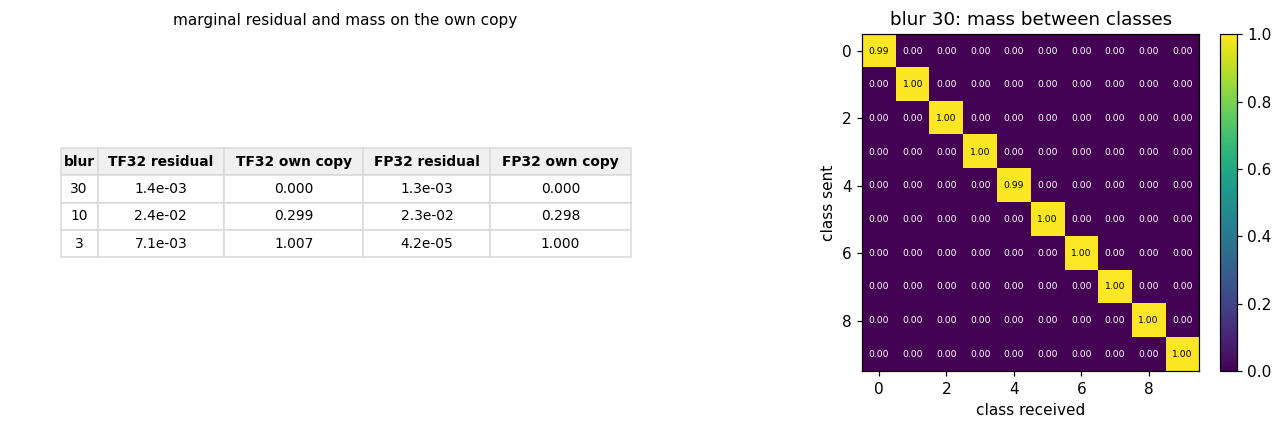